In [1]:
import kagglehub
from diffusers import DiffusionPipeline
import torch

2025-04-14 04:31:48.734688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744605109.030182      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744605109.117249      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:

# load both base & refiner
sdxl_model_path = kagglehub.model_download('stabilityai/stable-diffusion-xl/PyTorch/base-1-0/1')

base = DiffusionPipeline.from_pretrained(
    sdxl_model_path, torch_dtype=torch.float16, variant="fp16", use_safetensors=True
)
base.to("cuda:1")
base.unet = torch.compile(base.unet, mode="reduce-overhead", fullgraph=True)

refiner = DiffusionPipeline.from_pretrained(
    sdxl_model_path,
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)
refiner.to("cuda:1")
refiner.unet = torch.compile(refiner.unet, mode="reduce-overhead", fullgraph=True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [3]:
%%time

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A majestic lion jumping from a big stone at night"

# run both experts
image = base(
    prompt=prompt,
    width=512,
    height=512,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images
image = refiner(
    prompt=prompt,
    width=512,
    height=512,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

CPU times: user 3min, sys: 27.4 s, total: 3min 27s
Wall time: 3min 50s


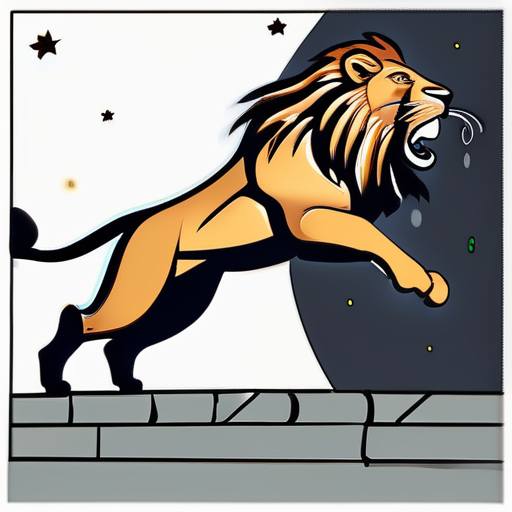

In [4]:
image

In [5]:
%%time

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8

prompt = "A majestic lion jumping from a big stone at night"

# run both experts
image = base(
    prompt=prompt,
    width=512,
    height=512,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images
image = refiner(
    prompt=prompt,
    width=512,
    height=512,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

CPU times: user 8.01 s, sys: 6.36 s, total: 14.4 s
Wall time: 14.3 s


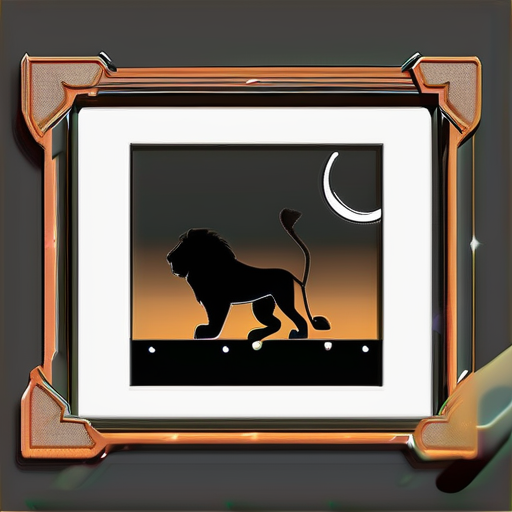

In [6]:
image